In [1]:
import numpy as np
import matplotlib.pyplot as plt

 Смоделировать и изобразить графически обучающие выборки объема N=50 для пяти нормально распределенных двумерных случайных векторов с заданными математическими ожидани- ями и самостоятельно подобранными корреляционными мат- рицами, которые обеспечивают линейную разделимость клас- сов

C:\Users\nasty\AppData\Local\Temp\ipykernel_11312\394930017.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  Xi = np.random.multivariate_normal(mean, cov, N)


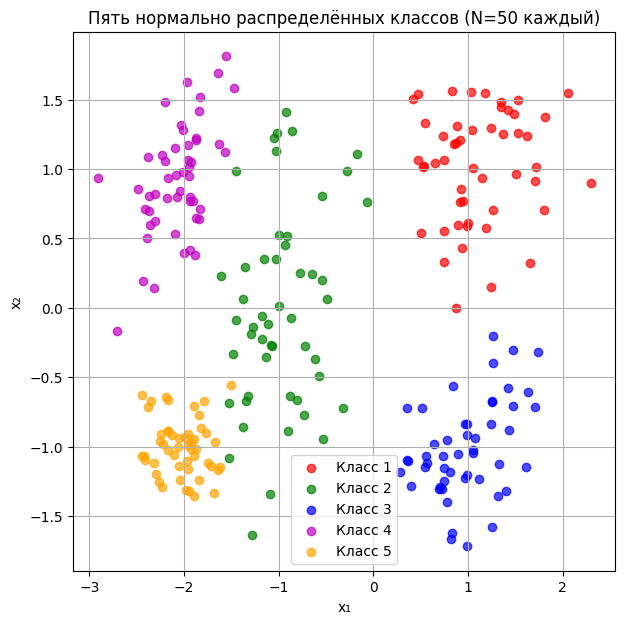

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def get_data(M, B, N):
    data = []
    labels = []

    for i, (mean, cov) in enumerate(zip(M, B), 1):
        Xi = np.random.multivariate_normal(mean, cov, N)
        data.append(Xi)
        labels.append(np.full(N, i))

    data = np.vstack(data)
    labels = np.concatenate(labels)
    return data, labels


N = 50
M = [
    np.array([1, 1]),
    np.array([-1, 0]),
    np.array([1, -1]),
    np.array([-2, 1]),
    np.array([-2, -1])
]
B = [
    np.array([[0.2, 0], 
              [0, 0.2]]),

    np.array([[0.1, 0.04], 
              [0.04, 0.4]]),

    np.array([[0.03, 0.1],
               [0.1, 0.03]]),

    np.array([[0.1, 0.12], 
              [0.02, 0.1]]),

    np.array([[0.06, 0], 
              [0, 0.06]])
]

#$np.random.seed(42)

data, labels = get_data(M, B, N)
# визуализация
plt.figure(figsize=(7, 7))
colors = ['r', 'g', 'b', 'm', 'orange']

for i in range(5):
    plt.scatter(data[labels == (i+1), 0],
                data[labels == (i+1), 1],
                label=f'Класс {i+1}', color=colors[i], alpha=0.7)

plt.title("Пять нормально распределённых классов (N=50 каждый)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.legend()
plt.grid(True)
plt.show()

# print(labels)


Объединить пять выборок в одну. Общее количество векторов в объединенной выборке должно быть 250. Полученная объ- единенная выборка используется для выполнения пунктов 3 и 4 настоящего плана

In [3]:
# --- объединяем все 5 классов в одну выборку ---
if not isinstance(labels[0], np.ndarray):
    N = 50
    labels = [np.full(N, i + 1) for i in range(5)]
    
X_total = np.vstack(data) 
y_total = np.concatenate(labels)  

print("Размер объединённой выборки:", X_total.shape)
print("Количество меток:", len(y_total))


Размер объединённой выборки: (250, 2)
Количество меток: 250


Разработать программу кластеризации данных с использова- нием минимаксного алгоритма. В качестве типичного рассто- яния взять половину среднего расстояния между существую- щими кластерами. Построить отображение результатов кла- стеризации для числа кластеров, начиная с двух. Построить график зависимости максимального (из минимальных) и ти- пичного расстояний от числа кластеров.

In [4]:
def compute_typical_distance(centers, eta=0.5):
    L = len(centers)
    if L < 2:
        return 0 

    total = 0     # сумма всех расстояний
    count = 0     # сколько пар посчитано

    for l in range(L - 1):
        for j in range(l + 1, L):
            dist = np.linalg.norm(centers[l] - centers[j])  # расстояние между центрами
            total += dist
            count += 1

    avg_dist = total / count
    d_typical = eta * avg_dist
    return d_typical


In [5]:
def minimax_clustering_full(X, eta=0.5, verbose=False):
    N = X.shape[0]
    centers = [X[np.random.randint(0, N)]]
    dmax_list, dtyp_list, k_values = [], [], []

    while True:
        # --- вычисляем расстояния каждой точки до ближайшего центра ---
        dists = np.array([min(np.linalg.norm(x - c) for c in centers) for x in X])
        max_dist = np.max(dists)
        new_center = X[np.argmax(dists)]
        centers.append(new_center)

        d_typical = compute_typical_distance(np.array(centers), eta)

        dmax_list.append(max_dist)
        dtyp_list.append(d_typical)
        k_values.append(len(centers)-1)

        if verbose:
            print(f"Кластеров: {len(centers)}, Dmax={max_dist:.3f}, Dtyp={d_typical:.3f}")

        if max_dist < d_typical:
            centers.pop()
            break

    centers = np.array(centers)

    # --- назначаем точки ближайшему центру ---
    labels = np.array([
        np.argmin([np.linalg.norm(x - c) for c in centers])
        for x in X
    ])

    return centers, labels, np.array(k_values), np.array(dmax_list), np.array(dtyp_list)


Кластеров: 2, Dmax=4.012, Dtyp=2.006
Кластеров: 3, Dmax=3.007, Dtyp=1.708
Кластеров: 4, Dmax=2.150, Dtyp=1.702
Кластеров: 5, Dmax=1.854, Dtyp=1.456
Кластеров: 6, Dmax=1.615, Dtyp=1.532
Кластеров: 7, Dmax=1.350, Dtyp=1.493
Найдено кластеров: 6


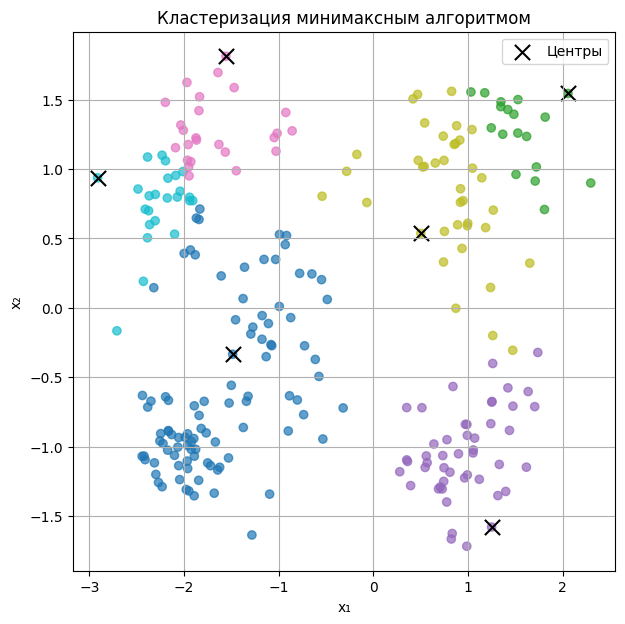

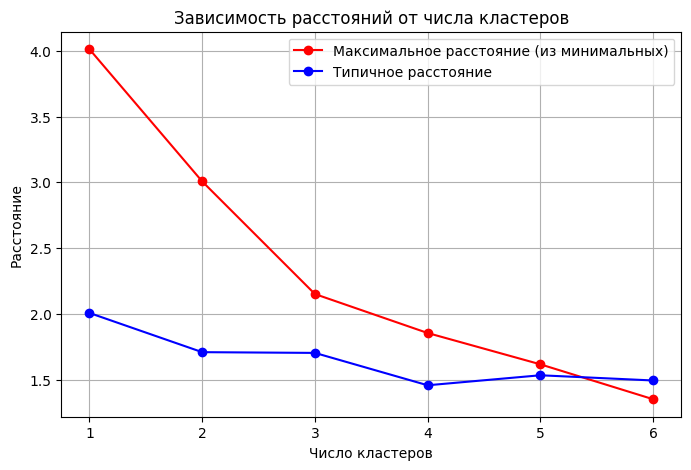

In [6]:
centers, labels, k_values, dmax_list, dtyp_list = minimax_clustering_full(X_total, eta=0.5, verbose=True)

print("Найдено кластеров:", len(centers))

plt.figure(figsize=(7,7))
plt.scatter(X_total[:,0], X_total[:,1], c=labels, cmap='tab10', alpha=0.7)
plt.scatter(centers[:,0], centers[:,1], c='black', marker='x', s=120, label='Центры')
plt.title("Кластеризация минимаксным алгоритмом")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(k_values, dmax_list, 'r-o', label='Максимальное расстояние (из минимальных)')
plt.plot(k_values, dtyp_list, 'b-o', label='Типичное расстояние')
plt.title("Зависимость расстояний от числа кластеров")
plt.xlabel("Число кластеров")
plt.ylabel("Расстояние")
plt.legend()
plt.grid(True)
plt.show()




Разработать программу кластеризации данных с использова- нием алгоритма K внутригрупповых средних для числа кла- стеров равного 3 и 5. Для ситуации 5 кластеров подобрать начальные условия так, чтобы получить два результата: а) чтобы кластеризация максимально соответствовала перво- начальному разбиению на классы («правильная» кластериза- ция); б) чтобы кластеризация максимально не соответствова-ла первоначальному разбиению на классы («неправильная» кластеризация). Для всех случаев построить графики зависи- мости числа векторов признаков, сменивших номер кластера, от номера итерации

In [7]:
def k_means(X, K, centers_init=None, max_iter=20):
    N = X.shape[0]

    if centers_init is None:
        idx = np.random.choice(N, K, replace=False)
        centers = X[idx]
    else:
        centers = np.copy(centers_init)

    labels = np.zeros(N, dtype=int)
    history = []

    while True:
        new_labels = np.array([np.argmin(np.linalg.norm(x - centers, axis=1)) for x in X])

        # --- Подсчёт, сколько точек изменили кластер ---
        changes = np.sum(new_labels != labels)
        history.append(changes)
        labels = new_labels

        # --- Пересчёт центров ---
        new_centers = np.array([
            X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
            for k in range(K)
        ])

        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    return centers, labels, history


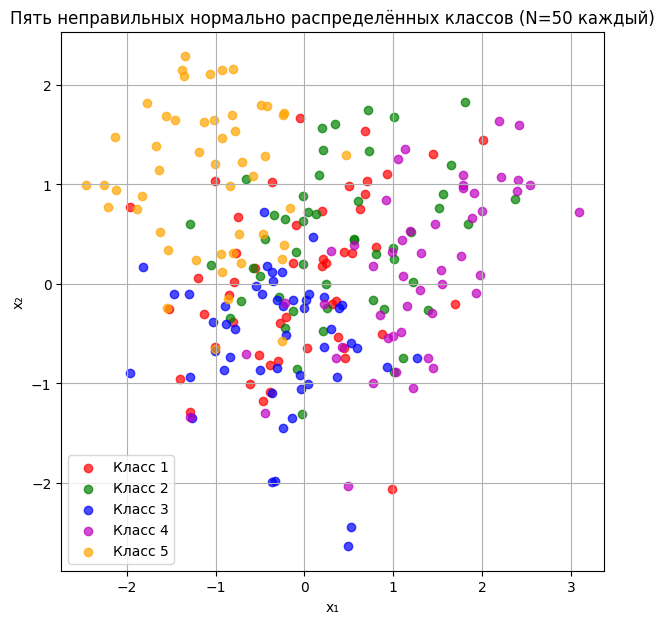

In [8]:

# centers_3, labels_3, history_3 = k_means(X_total, K=3, centers_init=M[:3])

# centers_5, labels_5, history_5 = k_means(X_total, K=5, centers_init=M)


centers_3, labels_3, history_3 = k_means(X_total, K=3)

centers_5, labels_5, history_5 = k_means(X_total, K=5)

M_bad = np.array([
    [0, 0],
    [0.5, 0.5],
    [-0.5, -0.5],
    [1, 0],
    [-1, 1]
])

B_bad = [
    np.array([[0.6, 0.2], 
              [0.2, 0.6]]),

    np.array([[0.5, 0.1], 
              [0.1, 0.5]]),

    np.array([[0.6, -0.2], 
              [-0.2, 0.6]]),

    np.array([[0.7, 0.3],
               [0.3, 0.7]]),

    np.array([[0.5, -0.1], 
              [-0.1, 0.5]])
]

data_bad, labels_bad = get_data(M_bad, B_bad, N)

plt.figure(figsize=(7, 7))
colors = ['r', 'g', 'b', 'm', 'orange']

for i in range(5):
    plt.scatter(data_bad[labels_bad == (i+1), 0],
                data_bad[labels_bad == (i+1), 1],
                label=f'Класс {i+1}', color=colors[i], alpha=0.7)

plt.title("Пять неправильных нормально распределённых классов (N=50 каждый)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.legend()
plt.grid(True)
plt.show()


X_total_bad = np.vstack(data_bad) 
centers_bad, labels_bad, history_bad = k_means(X_total_bad, K=5, centers_init=M_bad)


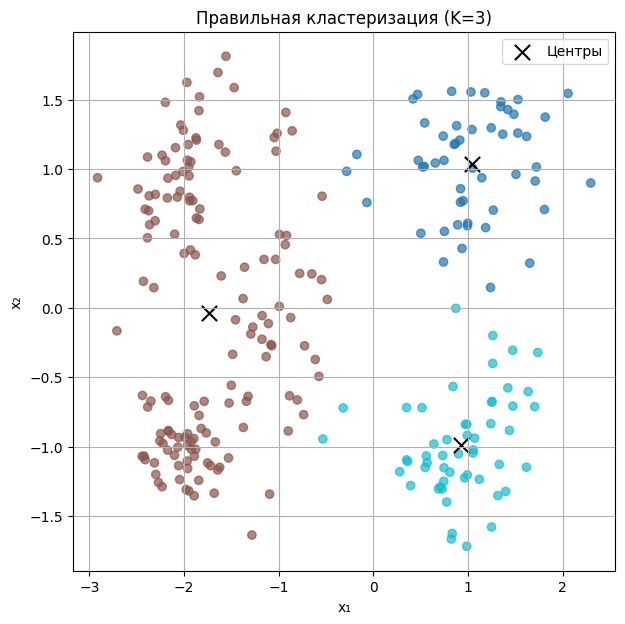

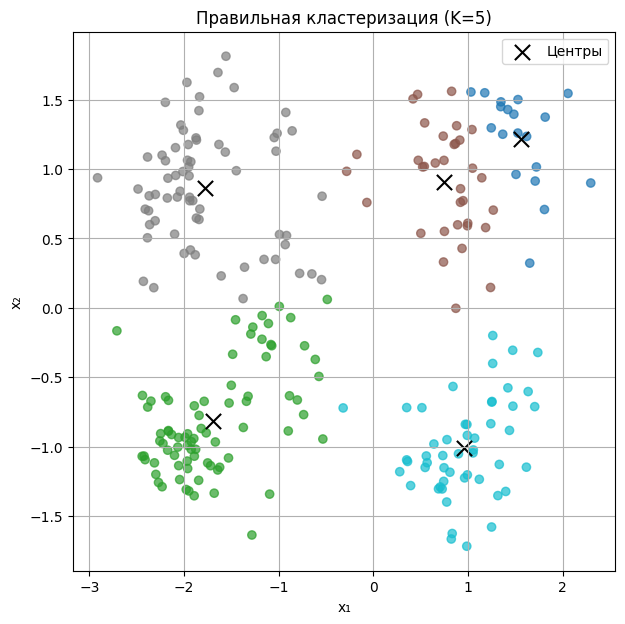

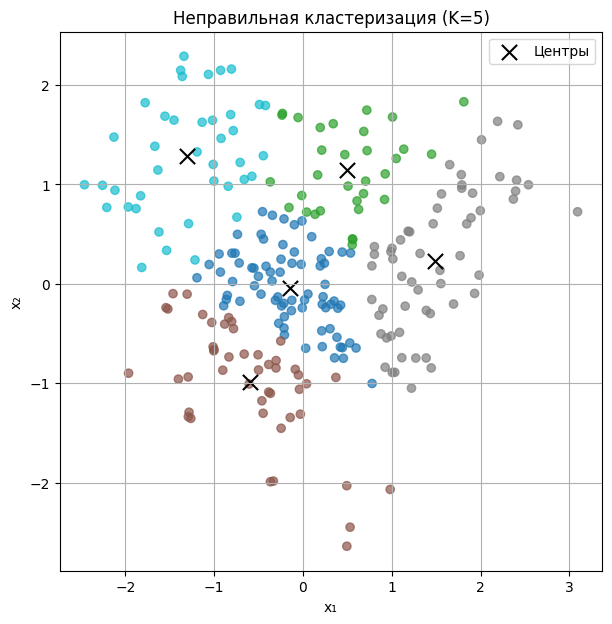

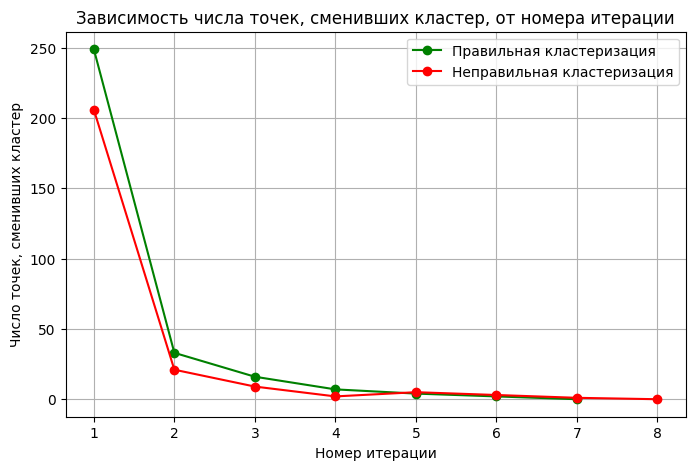

In [9]:
def plot_clusters(X, labels, centers, title):
    plt.figure(figsize=(7,7))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', alpha=0.7)
    plt.scatter(centers[:,0], centers[:,1], c='black', marker='x', s=120, label='Центры')
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_cluster_history(history_true, history_bad):
    """
    Строит график зависимости числа сменивших кластер точек от итерации
    для правильной и неправильной кластеризаций.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(history_true) + 1), history_true, 'g-o', label='Правильная кластеризация')
    plt.plot(range(1, len(history_bad) + 1), history_bad, 'r-o', label='Неправильная кластеризация')

    plt.title("Зависимость числа точек, сменивших кластер, от номера итерации")
    plt.xlabel("Номер итерации")
    plt.ylabel("Число точек, сменивших кластер")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_clusters(X_total, labels_3, centers_3, "Правильная кластеризация (K=3)")
plot_clusters(X_total, labels_5, centers_5, "Правильная кластеризация (K=5)")

plot_clusters(X_total_bad, labels_bad, centers_bad, "Неправильная кластеризация (K=5)")

plot_cluster_history(history_5, history_bad)
